In [1]:
import ccxt
import pandas as pd
import matplotlib.pyplot as plt 

exchange = ccxt.binance()

bars = exchange.fetch_ohlcv('BTC/USDT', timeframe='30m', limit=500)

df = pd.DataFrame(bars, columns=['time','open','high','low','close','volume'])

df['time'] = pd.to_datetime(df['time'], unit='ms')
df = df.set_index('time')

In [2]:
print(df)

                         open      high       low     close     volume
time                                                                  
2026-04-05 18:30:00  67299.53  67451.78  67299.53  67413.78  110.38660
2026-04-05 19:00:00  67413.78  67560.45  67364.61  67465.22  141.90208
2026-04-05 19:30:00  67465.22  67472.01  67276.67  67361.01   87.74170
2026-04-05 20:00:00  67361.01  67493.17  67332.66  67479.04  100.49110
2026-04-05 20:30:00  67479.04  67705.74  67467.73  67658.35  237.81256
...                       ...       ...       ...       ...        ...
2026-04-16 02:00:00  74657.67  74905.91  74601.27  74896.51  200.53069
2026-04-16 02:30:00  74896.52  75267.85  74810.17  74887.24  389.12546
2026-04-16 03:00:00  74887.23  75159.26  74876.37  75037.84  307.83818
2026-04-16 03:30:00  75037.85  75048.00  74865.50  74888.21  162.88148
2026-04-16 04:00:00  74888.21  75010.00  74839.51  74900.01  149.09039

[500 rows x 5 columns]


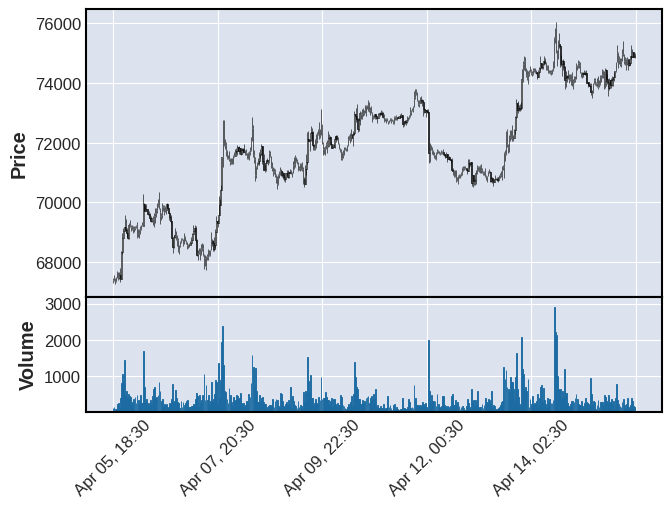

In [3]:
import mplfinance as mpf

mpf.plot(df, type='candle', volume=True)

In [4]:
print(df.columns)
print(df.head())

Index(['open', 'high', 'low', 'close', 'volume'], dtype='str')
                         open      high       low     close     volume
time                                                                  
2026-04-05 18:30:00  67299.53  67451.78  67299.53  67413.78  110.38660
2026-04-05 19:00:00  67413.78  67560.45  67364.61  67465.22  141.90208
2026-04-05 19:30:00  67465.22  67472.01  67276.67  67361.01   87.74170
2026-04-05 20:00:00  67361.01  67493.17  67332.66  67479.04  100.49110
2026-04-05 20:30:00  67479.04  67705.74  67467.73  67658.35  237.81256


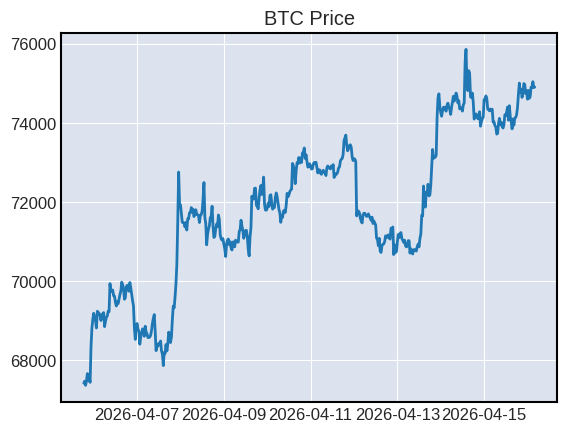

In [5]:


plt.plot(df.index, df['close'])
plt.title('BTC Price')
plt.show()

In [6]:

import ta

df['rsi'] = ta.momentum.RSIIndicator(df['close'], window=14).rsi() # amenta RSA

# add another colun for movingaverage 
# df['ma_fast'] = df['close'].rolling(10).mean()
# df['ma_slow'] = df['close'].rolling(30).mean()

# More signla 

df['ma_fast'] = df['close'].rolling(5).mean()
df['ma_slow'] = df['close'].rolling(10).mean()


In [7]:
# --- tune these ---
# Strict RSI (30/70) + MA almost never fires on 1m data. Use MA *crosses* for entries
# and a *loose* RSI filter (or set USE_RSI_FILTER = False to see MA-only trades).
USE_RSI_FILTER = True
RSI_LONG_MAX = 60   # long only if RSI below this at the cross (avoid buying exhausted spikes)
RSI_SHORT_MIN = 40  # short only if RSI above this at the cross

fast_above = df['ma_fast'] > df['ma_slow']
prev_above = fast_above.shift(1).fillna(False)

golden_cross = fast_above & ~prev_above   # fast crossed above slow
death_cross = ~fast_above & prev_above    # fast crossed below slow

long_entry = golden_cross
short_entry = death_cross
if USE_RSI_FILTER:
    long_entry = golden_cross & (df['rsi'] < RSI_LONG_MAX)
    short_entry = death_cross & (df['rsi'] > RSI_SHORT_MIN)

pos = 0
signals = []
for le, se in zip(long_entry, short_entry):
    if le:
        pos = 1
    elif se:
        pos = -1
    signals.append(pos)
df['signal'] = signals

print(df.head())
print("golden_cross:", golden_cross.sum(), "death_cross:", death_cross.sum())
print("long_entry:", long_entry.sum(), "short_entry:", short_entry.sum())
print("bars long:", (df['signal'] == 1).sum(), "bars short:", (df['signal'] == -1).sum())

                         open      high       low     close     volume  rsi  \
time                                                                          
2026-04-05 18:30:00  67299.53  67451.78  67299.53  67413.78  110.38660  NaN   
2026-04-05 19:00:00  67413.78  67560.45  67364.61  67465.22  141.90208  NaN   
2026-04-05 19:30:00  67465.22  67472.01  67276.67  67361.01   87.74170  NaN   
2026-04-05 20:00:00  67361.01  67493.17  67332.66  67479.04  100.49110  NaN   
2026-04-05 20:30:00  67479.04  67705.74  67467.73  67658.35  237.81256  NaN   

                      ma_fast  ma_slow  signal  
time                                            
2026-04-05 18:30:00       NaN      NaN       0  
2026-04-05 19:00:00       NaN      NaN       0  
2026-04-05 19:30:00       NaN      NaN       0  
2026-04-05 20:00:00       NaN      NaN       0  
2026-04-05 20:30:00  67475.48      NaN       0  
golden_cross: 271 death_cross: 31
long_entry: 138 short_entry: 28
bars long: 240 bars short: 237


In [ ]:
df['returns'] = df['close'].pct_change()

df['strategy_returns'] = df['signal'].shift(1) * df['returns']

start_money = 100

print(f"The total return: {df['strategy_returns'].sum() * 100}%")

print(f"The compunded Return {((df['strategy_returns'] + 1).prod() - 1) * 100}% ")


The total return: 0.8213190029186968%
The compunded Return 0.5700929936403698% 


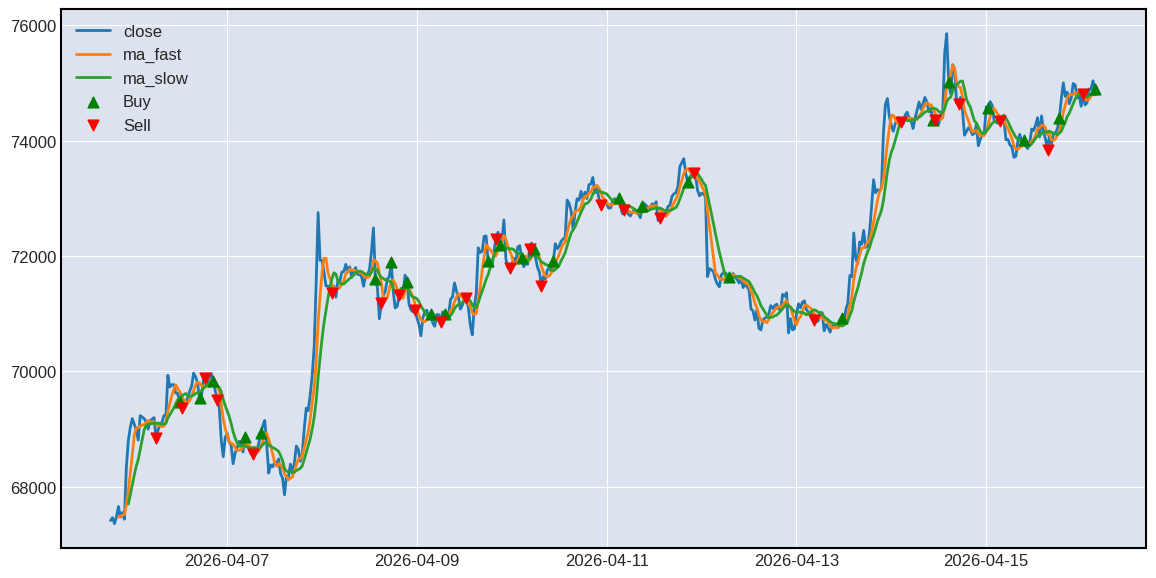

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

sig = df['signal']
buy = (sig == 1) & (sig.shift(1) != 1)
sell = (sig == -1) & (sig.shift(1) != -1)

plt.plot(df.index, df['close'], label='close')
plt.plot(df.index, df['ma_fast'], label='ma_fast')
plt.plot(df.index, df['ma_slow'], label='ma_slow')
plt.scatter(df.index[buy], df.loc[buy, 'close'], color='green', marker='^', s=60, zorder=5, label='Buy')
plt.scatter(df.index[sell], df.loc[sell, 'close'], color='red', marker='v', s=60, zorder=5, label='Sell')
plt.legend()
plt.show()

In [10]:
df.sample(20)

,open,high,low,close,volume,rsi,ma_fast,ma_slow,signal,returns,strategy_returns
time,,,,,,,,,,,
2026-04-11 07:00:00,72762.01,72832.00,72743.35,72799.11,207.74523,49.432771,72757.716,72815.858,-1,0.000510,-0.000510
2026-04-09 08:00:00,70982.01,71021.67,70865.42,70980.35,119.62104,47.643201,70971.270,70943.826,1,-0.000023,-0.000023
2026-04-13 13:00:00,71074.92,71267.74,71071.85,71185.04,300.46715,59.293930,70983.602,70870.543,1,0.001549,0.001549
2026-04-12 01:00:00,73079.96,73137.24,72981.54,73017.61,83.23729,45.222849,73073.346,73224.465,-1,-0.000853,0.000853
2026-04-11 14:00:00,72658.07,72770.91,72617.80,72712.93,109.02370,46.039929,72758.026,72815.388,-1,0.000755,-0.000755
2026-04-14 05:30:00,74339.78,74359.63,74150.60,74210.11,516.58872,62.879624,74375.234,74357.820,-1,-0.001744,0.001744
2026-04-11 15:30:00,72754.03,72872.54,72733.03,72858.17,148.26769,53.171076,72737.572,72784.707,-1,0.001432,-0.001432
2026-04-07 03:00:00,68674.01,68791.65,68625.59,68787.45,303.90857,42.591278,68633.900,68705.588,-1,0.001652,-0.001652
2026-04-10 19:30:00,72996.94,73264.76,72900.00,73236.11,403.74263,65.925870,73088.970,72941.648,1,0.003276,0.003276


In [11]:
import ccxt

print(ccxt.exchanges)

['aftermath', 'alpaca', 'apex', 'arkham', 'ascendex', 'aster', 'backpack', 'bequant', 'bigone', 'binance', 'binancecoinm', 'binanceus', 'binanceusdm', 'bingx', 'bit2c', 'bitbank', 'bitbns', 'bitfinex', 'bitflyer', 'bitget', 'bithumb', 'bitmart', 'bitmex', 'bitopro', 'bitrue', 'bitso', 'bitstamp', 'bitteam', 'bittrade', 'bitvavo', 'blockchaincom', 'blofin', 'btcbox', 'btcmarkets', 'btcturk', 'bullish', 'bybit', 'bydfi', 'cex', 'coinbase', 'coinbaseadvanced', 'coinbaseexchange', 'coinbaseinternational', 'coincheck', 'coinex', 'coinmate', 'coinmetro', 'coinone', 'coinsph', 'coinspot', 'cryptocom', 'cryptomus', 'deepcoin', 'delta', 'deribit', 'derive', 'digifinex', 'dydx', 'exmo', 'fmfwio', 'foxbit', 'gate', 'gateio', 'gemini', 'grvt', 'hashkey', 'hibachi', 'hitbtc', 'hollaex', 'htx', 'huobi', 'hyperliquid', 'independentreserve', 'indodax', 'kraken', 'krakenfutures', 'kucoin', 'kucoinfutures', 'latoken', 'lbank', 'lighter', 'luno', 'mercado', 'mexc', 'modetrade', 'myokx', 'ndax', 'novadax'